# 04 — EDA y gráficos obligatorios de AndinaLog 03B

## Objetivo

Explorar la tabla Gold antes de entrenar el modelo y responder, con gráficos y palabras sencillas, las preguntas indicadas en la tarea.

- **Unidad de observación:** una fila representa una lectura de telemetría.
- **Objetivo:** `desviacion_proximos_60min_flag`.
- **Importante:** este notebook solo analiza; no modifica ni reconstruye la tabla Gold.

## Antes de comenzar: palabras clave en lenguaje sencillo

- **Lectura:** una medición realizada por los sensores de un camión en un momento específico.
- **Viaje:** recorrido al que pertenece una lectura.
- **Desviación térmica actual:** en esa lectura, la temperatura ya está fuera del rango permitido.
- **Desviación futura:** durante los 60 minutos posteriores a la lectura aparecerá al menos una desviación térmica.
- **0:** no ocurrió la condición analizada.
- **1:** sí ocurrió la condición analizada.
- **Mediana:** valor central de un grupo. La mitad de las lecturas queda por debajo y la otra mitad por encima.
- **Variación en 30 minutos:** diferencia entre la temperatura actual y una lectura cercana a 30 minutos antes. Un valor positivo indica aumento; uno negativo indica disminución.

Este EDA describe lo que ocurrió en los datos históricos. Una diferencia entre grupos puede ser útil como señal, pero **no demuestra por sí sola que una variable sea la causa** de una desviación ni garantiza que permita predecir todos los casos.

## 1. Carga del dataset

In [1]:
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

RUTA_GOLD = Path("outputs/03_silver_gold_iot/andinalog_iot_modelado_gold.csv")
CARPETA_SALIDA = Path("outputs/04_eda_gold_iot")
RUTA_INFORME = CARPETA_SALIDA / "Informe_04_EDA_Gold_IoT.md"
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

if not RUTA_GOLD.exists():
    alternativa = Path("/content/andinalog_iot_modelado_gold.csv")
    if alternativa.exists():
        RUTA_GOLD = alternativa
    else:
        raise FileNotFoundError("No se encontró el CSV Gold. Ajusta RUTA_GOLD.")

gold = pd.read_csv(RUTA_GOLD)
gold["timestamp"] = pd.to_datetime(gold["timestamp"], errors="coerce", utc=True)

objetivo = "desviacion_proximos_60min_flag"
temp = "temperatura_cabina_c"
humedad = "humedad_cabina_pct"
flag_actual = "desviacion_termica_flag"
temp_anterior = "temperatura_anterior"
variacion_30 = "variacion_temperatura_30min"
predictores_minimos = [temp, humedad, flag_actual, temp_anterior, variacion_30]

faltantes = [c for c in predictores_minimos + [objetivo] if c not in gold.columns]
if faltantes:
    raise ValueError(f"Faltan columnas obligatorias: {faltantes}")

print("Archivo cargado:", RUTA_GOLD.resolve())
print(f"Gold: {gold.shape[0]:,} filas y {gold.shape[1]} columnas")

Archivo cargado: C:\Users\remrodri\Documents\Codex\2026-09-28\referenced-chatgpt-conversation-this-is-an\outputs\03_silver_gold_iot\andinalog_iot_modelado_gold.csv
Gold: 28,465 filas y 17 columnas


## 2. EDA común

In [2]:
print("1. Número de filas y columnas")
print(f"Filas: {gold.shape[0]:,} | Columnas: {gold.shape[1]}")

print("\n2. Unidad de observación")
print("Una fila representa una lectura de telemetría de un viaje en un momento determinado.")

print("\n3. Duplicados")
print("Filas completamente duplicadas:", int(gold.duplicated().sum()))
print("Duplicados por viaje + timestamp:", int(gold.duplicated(["viaje_id", "timestamp"]).sum()))

1. Número de filas y columnas
Filas: 28,465 | Columnas: 17

2. Unidad de observación
Una fila representa una lectura de telemetría de un viaje en un momento determinado.

3. Duplicados
Filas completamente duplicadas: 0
Duplicados por viaje + timestamp: 0


In [3]:
print("4. Valores faltantes")
resumen_faltantes = pd.DataFrame({
    "faltantes": gold.isna().sum(),
    "porcentaje": (gold.isna().mean() * 100).round(2),
})
display(resumen_faltantes.loc[resumen_faltantes["faltantes"] > 0])

esperados = {
    "temperatura_anterior",
    "ts_temperatura_anterior",
    "variacion_temperatura_30min",
    "ts_base_variacion",
    "desviacion_proximos_60min_flag",
}
columnas_con_faltantes = set(resumen_faltantes.query("faltantes > 0").index)
inesperados = sorted(columnas_con_faltantes - esperados)

print("Interpretación sencilla:")
print("- Los faltantes de temperatura anterior aparecen al inicio de cada viaje.")
print("- La variación queda vacía cuando no existe una lectura cercana a 30 minutos atrás.")
print("- El objetivo queda vacío cuando no existen 60 minutos futuros completos.")
print("- Columnas con faltantes inesperados:", inesperados if inesperados else "ninguna")

4. Valores faltantes


,faltantes,porcentaje
temperatura_anterior,1200,4.22
ts_temperatura_anterior,1200,4.22
variacion_temperatura_30min,1504,5.28
ts_base_variacion,1504,5.28
desviacion_proximos_60min_flag,2668,9.37


Interpretación sencilla:
- Los faltantes de temperatura anterior aparecen al inicio de cada viaje.
- La variación queda vacía cuando no existe una lectura cercana a 30 minutos atrás.
- El objetivo queda vacío cuando no existen 60 minutos futuros completos.
- Columnas con faltantes inesperados: ninguna


In [4]:
print("5. Tipos de datos")
display(gold.dtypes.rename("tipo").to_frame())

print("6. Estadísticas descriptivas")
display(gold[predictores_minimos + [objetivo]].describe().T.round(2))

print("7. Verificación de que no se multiplicaron registros")
duplicados_clave = int(gold.duplicated(["viaje_id", "timestamp"]).sum())
if duplicados_clave == 0:
    print("No se multiplicaron lecturas: cada viaje + timestamp aparece una sola vez.")
else:
    print(f"Revisar: existen {duplicados_clave} claves repetidas.")

5. Tipos de datos


,tipo
_fila_bronze,int64
timestamp,"datetime64[us, UTC]"
viaje_id,str
order_id,str
camion_id,str
producto_id,str
temperatura_cabina_c,float64
humedad_cabina_pct,float64
desviacion_termica_flag,int64
temperatura_anterior,float64


6. Estadísticas descriptivas


,count,mean,std,min,25%,50%,75%,max
temperatura_cabina_c,28465.0,8.34,14.05,-21.63,3.44,15.61,20.05,29.69
humedad_cabina_pct,28465.0,61.48,15.46,20.70,48.00,60.30,75.10,100.00
desviacion_termica_flag,28465.0,0.03,0.18,0.00,0.00,0.00,0.00,1.00
temperatura_anterior,27265.0,8.35,14.04,-21.63,3.44,15.65,20.05,29.69
variacion_temperatura_30min,26961.0,-0.00,2.10,-11.28,-1.14,-0.02,1.13,12.78
desviacion_proximos_60min_flag,25797.0,0.05,0.22,0.00,0.00,0.00,0.00,1.00


7. Verificación de que no se multiplicaron registros
No se multiplicaron lecturas: cada viaje + timestamp aparece una sola vez.


In [5]:
# Los gráficos del objetivo usan solo las ventanas donde se pudieron observar 60 minutos futuros.
analisis = gold.loc[gold[objetivo].notna()].copy()
analisis[objetivo] = analisis[objetivo].astype(int)

print(f"Total Gold: {len(gold):,} lecturas")
print(f"Lecturas usadas para analizar el objetivo: {len(analisis):,}")
print(f"Ventanas no evaluables excluidas de los gráficos del objetivo: {gold[objetivo].isna().sum():,}")

Total Gold: 28,465 lecturas
Lecturas usadas para analizar el objetivo: 25,797
Ventanas no evaluables excluidas de los gráficos del objetivo: 2,668


### Interpretación del control inicial

La tabla Gold contiene **28.465 lecturas y 17 columnas**. Cada fila corresponde a una lectura tomada durante un viaje. No se encontraron filas duplicadas ni combinaciones repetidas de viaje y momento, por lo que no hay evidencia de que los cruces hayan copiado o multiplicado lecturas.

Los espacios vacíos tienen una explicación relacionada con el tiempo:

- En **1.200 lecturas** no existe una temperatura anterior porque son las primeras observaciones de sus viajes.
- En **1.504 lecturas** no se puede calcular el cambio de 30 minutos porque no existe una medición anterior suficientemente cercana a ese momento.
- En **2.668 lecturas** no se puede saber qué ocurrió durante los siguientes 60 minutos porque el viaje termina antes de completar esa hora.

Estos vacíos no significan automáticamente que los sensores estén dañados. Son casos en los que no existe suficiente historia previa o tiempo futuro para hacer el cálculo. No se encontraron faltantes inesperados.

Para estudiar la desviación futura se utilizarán **25.797 lecturas evaluables**. Las otras **2.668 lecturas** permanecen en Gold, pero no participan en los gráficos que requieren conocer los 60 minutos posteriores. Así se evita convertir un dato desconocido en un “no ocurrió”.

## 3. Gráficos obligatorios

### Gráfico 1. Frecuencia del objetivo

**Pregunta que responde: ¿Qué tan poco frecuentes son las desviaciones futuras?**

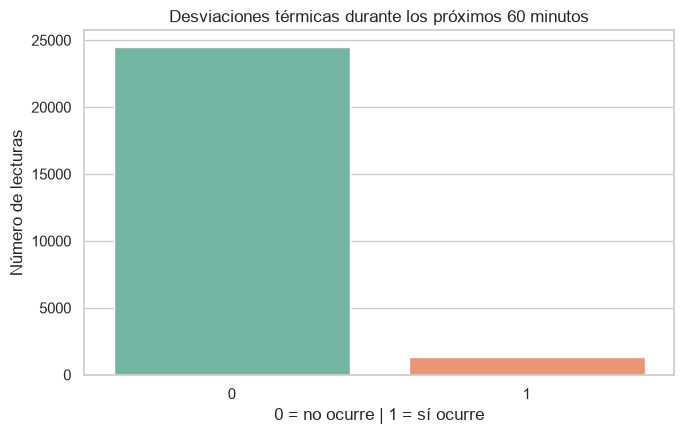

In [6]:
plt.figure(figsize=(7, 4.5))
sns.countplot(data=analisis, x=objetivo, hue=objetivo, palette="Set2", legend=False)
plt.title("Desviaciones térmicas durante los próximos 60 minutos")
plt.xlabel("0 = no ocurre | 1 = sí ocurre")
plt.ylabel("Número de lecturas")
plt.tight_layout()
plt.show()

In [7]:
conteos = analisis[objetivo].value_counts().reindex([0, 1], fill_value=0)
porcentajes = conteos / conteos.sum() * 100
print("Pregunta que responde: ¿Qué tan poco frecuentes son las desviaciones futuras?")
print(f"De {len(analisis):,} lecturas evaluables, {conteos[1]:,} ({porcentajes[1]:.2f}%) anuncian una desviación futura.")
if porcentajes[1] < 10:
    print("Interpretación sencilla: son casos muy poco frecuentes frente a las lecturas sin desviación futura.")
elif porcentajes[1] < 30:
    print("Interpretación sencilla: son menos frecuentes, aunque aparecen en una parte visible de los datos.")
else:
    print("Interpretación sencilla: representan una parte importante de las lecturas.")

Pregunta que responde: ¿Qué tan poco frecuentes son las desviaciones futuras?
De 25,797 lecturas evaluables, 1,296 (5.02%) anuncian una desviación futura.
Interpretación sencilla: son casos muy poco frecuentes frente a las lecturas sin desviación futura.


### Interpretación del gráfico 1

**Pregunta que responde: ¿Qué tan poco frecuentes son las desviaciones futuras?**

De las **25.797 lecturas** en las que fue posible observar la hora siguiente, **1.296 lecturas (5,02%)** estuvieron seguidas por una desviación térmica y **24.501 (94,98%)** no lo estuvieron.

En palabras sencillas: aproximadamente **5 de cada 100 lecturas** anuncian una desviación futura, mientras que cerca de **95 de cada 100** no la anuncian. Por eso la barra correspondiente al valor 0 es mucho más alta.

**Conclusión práctica:** las desviaciones futuras son poco frecuentes. Esto es importante para el modelo posterior, porque acertar casi siempre “no habrá desviación” podría producir una exactitud aparentemente alta y, aun así, no detectar los pocos casos que realmente importan. El gráfico describe la frecuencia; todavía no indica qué variable causa las desviaciones.

### Gráfico 2. Temperatura actual según el resultado futuro

**Pregunta que responde: ¿Las futuras desviaciones parten de temperaturas diferentes?**

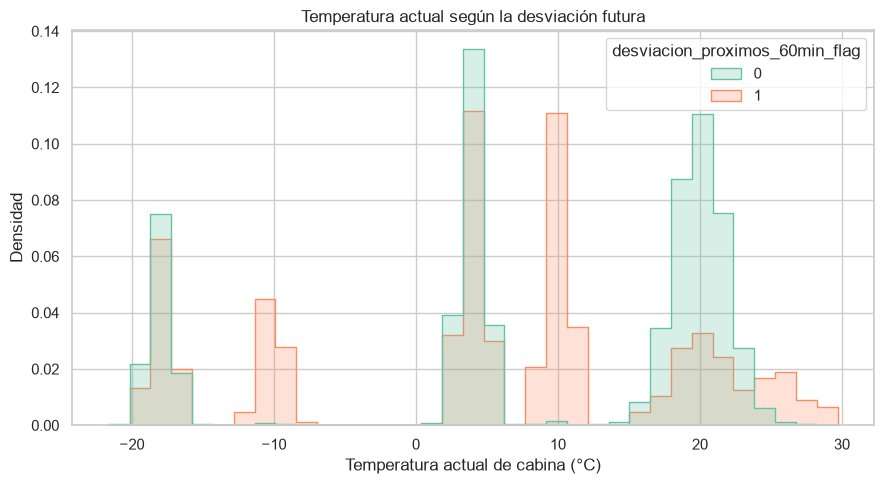

In [8]:
datos_g2 = analisis.loc[analisis[temp].notna()]
plt.figure(figsize=(9, 5))
sns.histplot(
    data=datos_g2, x=temp, hue=objetivo, bins=35,
    element="step", stat="density", common_norm=False, palette="Set2",
)
plt.title("Temperatura actual según la desviación futura")
plt.xlabel("Temperatura actual de cabina (°C)")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

In [9]:
med_temp = datos_g2.groupby(objetivo)[temp].median().reindex([0, 1])
diferencia_temp = med_temp[1] - med_temp[0]
print("Pregunta que responde: ¿Las futuras desviaciones parten de temperaturas diferentes?")
print(f"Mediana sin desviación futura: {med_temp[0]:.2f} °C.")
print(f"Mediana con desviación futura: {med_temp[1]:.2f} °C.")
if abs(diferencia_temp) < 0.5:
    print("Interpretación sencilla: las temperaturas centrales son parecidas; no se observa una diferencia clara por sí sola.")
else:
    sentido = "más alta" if diferencia_temp > 0 else "más baja"
    print(f"Interpretación sencilla: las desviaciones futuras parten, en general, de una temperatura {sentido} por {abs(diferencia_temp):.2f} °C.")

Pregunta que responde: ¿Las futuras desviaciones parten de temperaturas diferentes?
Mediana sin desviación futura: 16.73 °C.
Mediana con desviación futura: 5.24 °C.
Interpretación sencilla: las desviaciones futuras parten, en general, de una temperatura más baja por 11.49 °C.


### Interpretación del gráfico 2

**Pregunta que responde: ¿Las futuras desviaciones parten de temperaturas diferentes?**

La temperatura central o mediana fue de **16,73 °C** cuando no apareció una desviación durante la hora siguiente y de **5,24 °C** cuando sí apareció. La diferencia entre ambas medianas es de **11,49 °C**.

En palabras sencillas: en este conjunto de datos, las lecturas que luego tuvieron una desviación futura comenzaban, por lo general, con una temperatura bastante más baja. En el gráfico esto se aprecia porque la distribución de la clase 1 se concentra más hacia las temperaturas bajas.

**Conclusión práctica:** la temperatura actual contiene una señal útil para distinguir situaciones de mayor riesgo. Sin embargo, las distribuciones pueden superponerse: una temperatura baja no significa automáticamente que ocurrirá una desviación, y una temperatura más alta no garantiza que no ocurrirá. Este gráfico muestra una relación histórica, no una causa comprobada. Además, es un resultado general que mezcla productos con temperaturas de operación diferentes; por eso debe leerse junto con el análisis por producto incluido más adelante.

### Gráfico 3. Humedad actual por clase

**Pregunta que responde: ¿La humedad cambia antes de una desviación?**

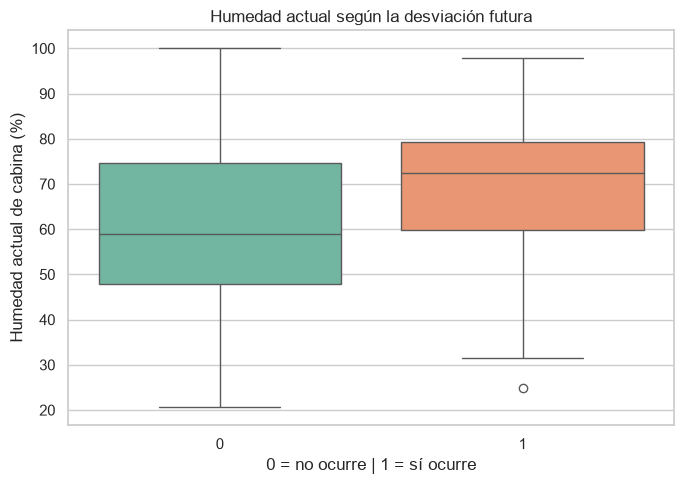

In [10]:
datos_g3 = analisis.loc[analisis[humedad].notna()]
plt.figure(figsize=(7, 5))
sns.boxplot(data=datos_g3, x=objetivo, y=humedad, hue=objetivo, palette="Set2", legend=False)
plt.title("Humedad actual según la desviación futura")
plt.xlabel("0 = no ocurre | 1 = sí ocurre")
plt.ylabel("Humedad actual de cabina (%)")
plt.tight_layout()
plt.show()

In [11]:
med_humedad = datos_g3.groupby(objetivo)[humedad].median().reindex([0, 1])
diferencia_humedad = med_humedad[1] - med_humedad[0]
print("Pregunta que responde: ¿La humedad cambia antes de una desviación?")
print(f"Mediana sin desviación futura: {med_humedad[0]:.2f}%.")
print(f"Mediana con desviación futura: {med_humedad[1]:.2f}%.")
if abs(diferencia_humedad) < 2:
    print("Interpretación sencilla: las humedades centrales son parecidas; el cambio no es claro en este gráfico.")
else:
    sentido = "mayor" if diferencia_humedad > 0 else "menor"
    print(f"Interpretación sencilla: antes de una desviación futura, la humedad suele ser {sentido} por {abs(diferencia_humedad):.2f} puntos porcentuales.")

Pregunta que responde: ¿La humedad cambia antes de una desviación?
Mediana sin desviación futura: 59.00%.
Mediana con desviación futura: 72.40%.
Interpretación sencilla: antes de una desviación futura, la humedad suele ser mayor por 13.40 puntos porcentuales.


### Interpretación del gráfico 3

**Pregunta que responde: ¿La humedad cambia antes de una desviación?**

La humedad mediana fue de **59,00%** en las lecturas sin desviación futura y de **72,40%** en las lecturas que sí estuvieron seguidas por una desviación. La diferencia es de **13,40 puntos porcentuales**.

Para leer el boxplot, la línea dentro de cada caja representa el valor central; la caja resume dónde se concentra la mitad central de las lecturas; y los puntos o extremos más alejados representan valores menos comunes.

En palabras sencillas: las desviaciones futuras estuvieron asociadas, en general, con ambientes más húmedos. **Conclusión práctica:** la humedad puede aportar información para reconocer situaciones de riesgo, pero existe variación dentro de ambos grupos. Por eso no debe utilizarse sola como una regla del tipo “humedad alta = desviación segura”. Tampoco puede afirmarse con este gráfico que la humedad sea la causa directa.

### Gráfico 4. Desviación actual y desviación futura

**Pregunta que responde: ¿Una desviación presente anticipa otra en la siguiente hora?**

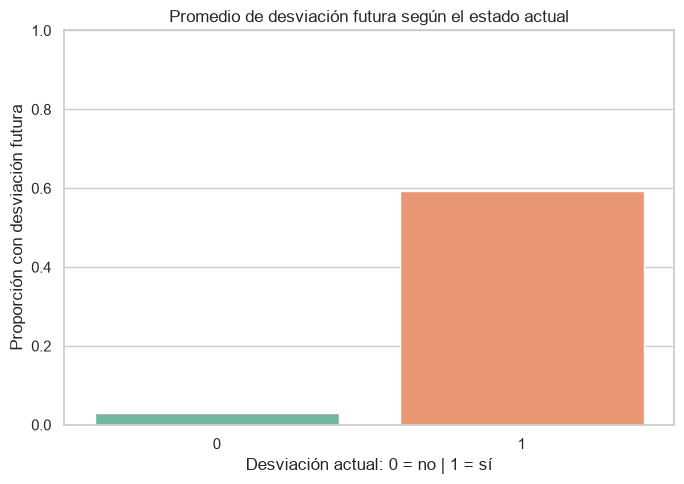

In [12]:
datos_g4 = analisis.loc[analisis[flag_actual].notna()]
plt.figure(figsize=(7, 5))
sns.barplot(
    data=datos_g4, x=flag_actual, y=objetivo, hue=flag_actual,
    estimator="mean", errorbar=None, palette="Set2", legend=False,
)
plt.title("Promedio de desviación futura según el estado actual")
plt.xlabel("Desviación actual: 0 = no | 1 = sí")
plt.ylabel("Proporción con desviación futura")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [13]:
tasas_actual = datos_g4.groupby(flag_actual)[objetivo].mean().reindex([0, 1])
diferencia_tasa = (tasas_actual[1] - tasas_actual[0]) * 100
print("Pregunta que responde: ¿Una desviación presente anticipa otra en la siguiente hora?")
print(f"Sin desviación actual: {tasas_actual[0] * 100:.2f}% presenta una desviación futura.")
print(f"Con desviación actual: {tasas_actual[1] * 100:.2f}% presenta una desviación futura.")
if abs(diferencia_tasa) < 2:
    print("Interpretación sencilla: la diferencia es pequeña; no cambia claramente la frecuencia futura.")
elif diferencia_tasa > 0:
    print(f"Interpretación sencilla: sí parece anticiparla, porque la frecuencia futura aumenta {diferencia_tasa:.2f} puntos porcentuales.")
else:
    print(f"Interpretación sencilla: en estos datos no la anticipa; la frecuencia futura disminuye {abs(diferencia_tasa):.2f} puntos porcentuales.")

Pregunta que responde: ¿Una desviación presente anticipa otra en la siguiente hora?
Sin desviación actual: 3.03% presenta una desviación futura.
Con desviación actual: 59.41% presenta una desviación futura.
Interpretación sencilla: sí parece anticiparla, porque la frecuencia futura aumenta 56.38 puntos porcentuales.


### Interpretación del gráfico 4

**Pregunta que responde: ¿Una desviación presente anticipa otra en la siguiente hora?**

Cuando la lectura actual **no** estaba en desviación térmica, solo **3,03%** presentó una desviación durante los siguientes 60 minutos. Cuando la lectura actual **ya estaba** en desviación, **59,41%** volvió a presentar o mantuvo una desviación dentro de la hora siguiente. La diferencia es de **56,38 puntos porcentuales**.

En términos fáciles de imaginar:

- Sin desviación actual, aproximadamente **3 de cada 100 lecturas** terminan asociadas con una desviación futura.
- Con desviación actual, aproximadamente **59 de cada 100 lecturas** están asociadas con una desviación futura.

**Conclusión práctica:** el estado actual es la señal individual más clara observada en estos gráficos. También explica parte del comportamiento visto después en el modelo: resulta mucho más sencillo reconocer riesgo cuando el problema ya comenzó. Aun así, no es una regla perfecta: alrededor de 41 de cada 100 lecturas con desviación actual no presentan una desviación en la ventana futura, y también existen casos futuros que comienzan cuando la lectura actual todavía estaba normal.

### Gráfico 5. Nivel y tendencia de la temperatura

**Pregunta que responde: ¿La combinación de nivel y tendencia permite reconocer el riesgo?**

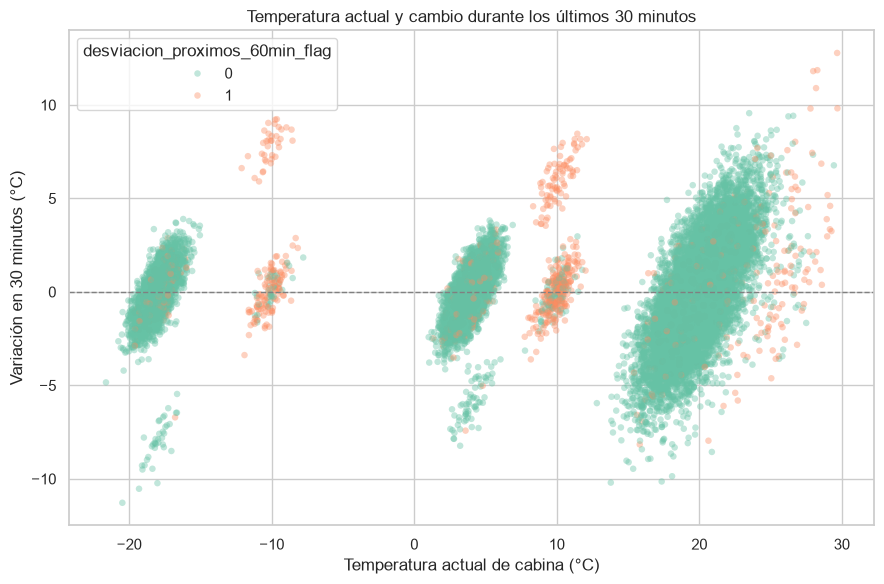

In [14]:
datos_g5 = analisis.loc[analisis[[temp, variacion_30]].notna().all(axis=1)]
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=datos_g5, x=temp, y=variacion_30, hue=objetivo,
    palette="Set2", alpha=0.4, s=22, linewidth=0,
)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Temperatura actual y cambio durante los últimos 30 minutos")
plt.xlabel("Temperatura actual de cabina (°C)")
plt.ylabel("Variación en 30 minutos (°C)")
plt.tight_layout()
plt.show()

In [15]:
centros = datos_g5.groupby(objetivo)[[temp, variacion_30]].median().reindex([0, 1])
dif_nivel = centros.loc[1, temp] - centros.loc[0, temp]
dif_tendencia = centros.loc[1, variacion_30] - centros.loc[0, variacion_30]
print("Pregunta que responde: ¿La combinación de nivel y tendencia permite reconocer el riesgo?")
print(f"Sin desviación futura: mediana de {centros.loc[0, temp]:.2f} °C y cambio de {centros.loc[0, variacion_30]:.2f} °C/30 min.")
print(f"Con desviación futura: mediana de {centros.loc[1, temp]:.2f} °C y cambio de {centros.loc[1, variacion_30]:.2f} °C/30 min.")
if abs(dif_nivel) < 0.5 and abs(dif_tendencia) < 0.5:
    print("Interpretación sencilla: los centros de ambos grupos son parecidos; la combinación no forma una separación clara.")
else:
    print(f"Interpretación sencilla: el grupo con riesgo cambia {dif_nivel:+.2f} °C en nivel y {dif_tendencia:+.2f} °C en tendencia frente al grupo sin riesgo.")
    print("La combinación aporta una señal descriptiva, aunque la superposición de colores indica que no identifica todos los casos por sí sola.")

Pregunta que responde: ¿La combinación de nivel y tendencia permite reconocer el riesgo?
Sin desviación futura: mediana de 16.80 °C y cambio de -0.03 °C/30 min.
Con desviación futura: mediana de 5.33 °C y cambio de 0.22 °C/30 min.
Interpretación sencilla: el grupo con riesgo cambia -11.46 °C en nivel y +0.25 °C en tendencia frente al grupo sin riesgo.
La combinación aporta una señal descriptiva, aunque la superposición de colores indica que no identifica todos los casos por sí sola.


### Interpretación del gráfico 5

**Pregunta que responde: ¿La combinación de nivel y tendencia permite reconocer el riesgo?**

Cada punto representa una lectura. Su posición horizontal muestra la temperatura actual y su posición vertical indica cuánto cambió en aproximadamente 30 minutos. Los colores separan las lecturas sin desviación futura de las que sí tuvieron una.

- Sin desviación futura: temperatura mediana de **16,80 °C** y variación mediana de **−0,03 °C en 30 minutos**, es decir, prácticamente estable.
- Con desviación futura: temperatura mediana de **5,33 °C** y variación mediana de **+0,22 °C en 30 minutos**, es decir, un aumento pequeño en el valor central.

La diferencia más visible está en el **nivel de temperatura**: el grupo con desviación futura parte unos **11,46 °C más abajo**. La diferencia de tendencia es mucho menor, de **0,25 °C en 30 minutos**.

**Conclusión práctica:** observar conjuntamente la temperatura y su cambio aporta contexto, pero los colores se mezclan en varias zonas. Esto significa que estas dos variables ayudan a describir el riesgo, aunque no separan perfectamente todos los casos y no deberían convertirse por sí solas en una regla automática.

## 4. Análisis complementario por producto

**Pregunta que responde: ¿La temperatura y el riesgo son iguales para todos los productos?**

Este análisis se agrega porque distintos productos pueden necesitar condiciones térmicas diferentes. Comparar todas las temperaturas juntas puede mezclar situaciones normales de un producto con situaciones anormales de otro.

La tabla y los gráficos siguientes muestran, para cada `producto_id`, la temperatura mediana observada y el porcentaje de lecturas asociadas con una desviación durante los siguientes 60 minutos.

**Importante:** los grupos térmicos se construyen únicamente para resumir las temperaturas observadas en los datos. No representan rangos permitidos ni especificaciones comerciales, porque no se proporcionó una tabla con los límites correctos de cada producto.

,lecturas,viajes,temperatura_mediana,temperatura_minima,temperatura_maxima,desviaciones_futuras,riesgo_futuro_pct,grupo_termico_observado
producto_id,,,,,,,,
PROD-035,282,13,-18.04,-20.24,-15.67,8,2.84,Mediana menor a 0 °C
PROD-011,456,21,-18.03,-20.01,-9.90,17,3.73,Mediana menor a 0 °C
PROD-043,466,22,-17.99,-20.59,-9.72,28,6.01,Mediana menor a 0 °C
PROD-025,448,21,-17.98,-21.63,-8.17,35,7.81,Mediana menor a 0 °C
PROD-060,448,21,-17.98,-20.11,-9.29,27,6.03,Mediana menor a 0 °C
PROD-054,471,22,-17.95,-20.76,-8.53,46,9.77,Mediana menor a 0 °C
PROD-058,539,25,-17.94,-20.48,-7.79,30,5.57,Mediana menor a 0 °C
PROD-051,584,27,-17.94,-20.17,-8.61,62,10.62,Mediana menor a 0 °C
PROD-008,492,23,-17.89,-20.40,-8.32,54,10.98,Mediana menor a 0 °C


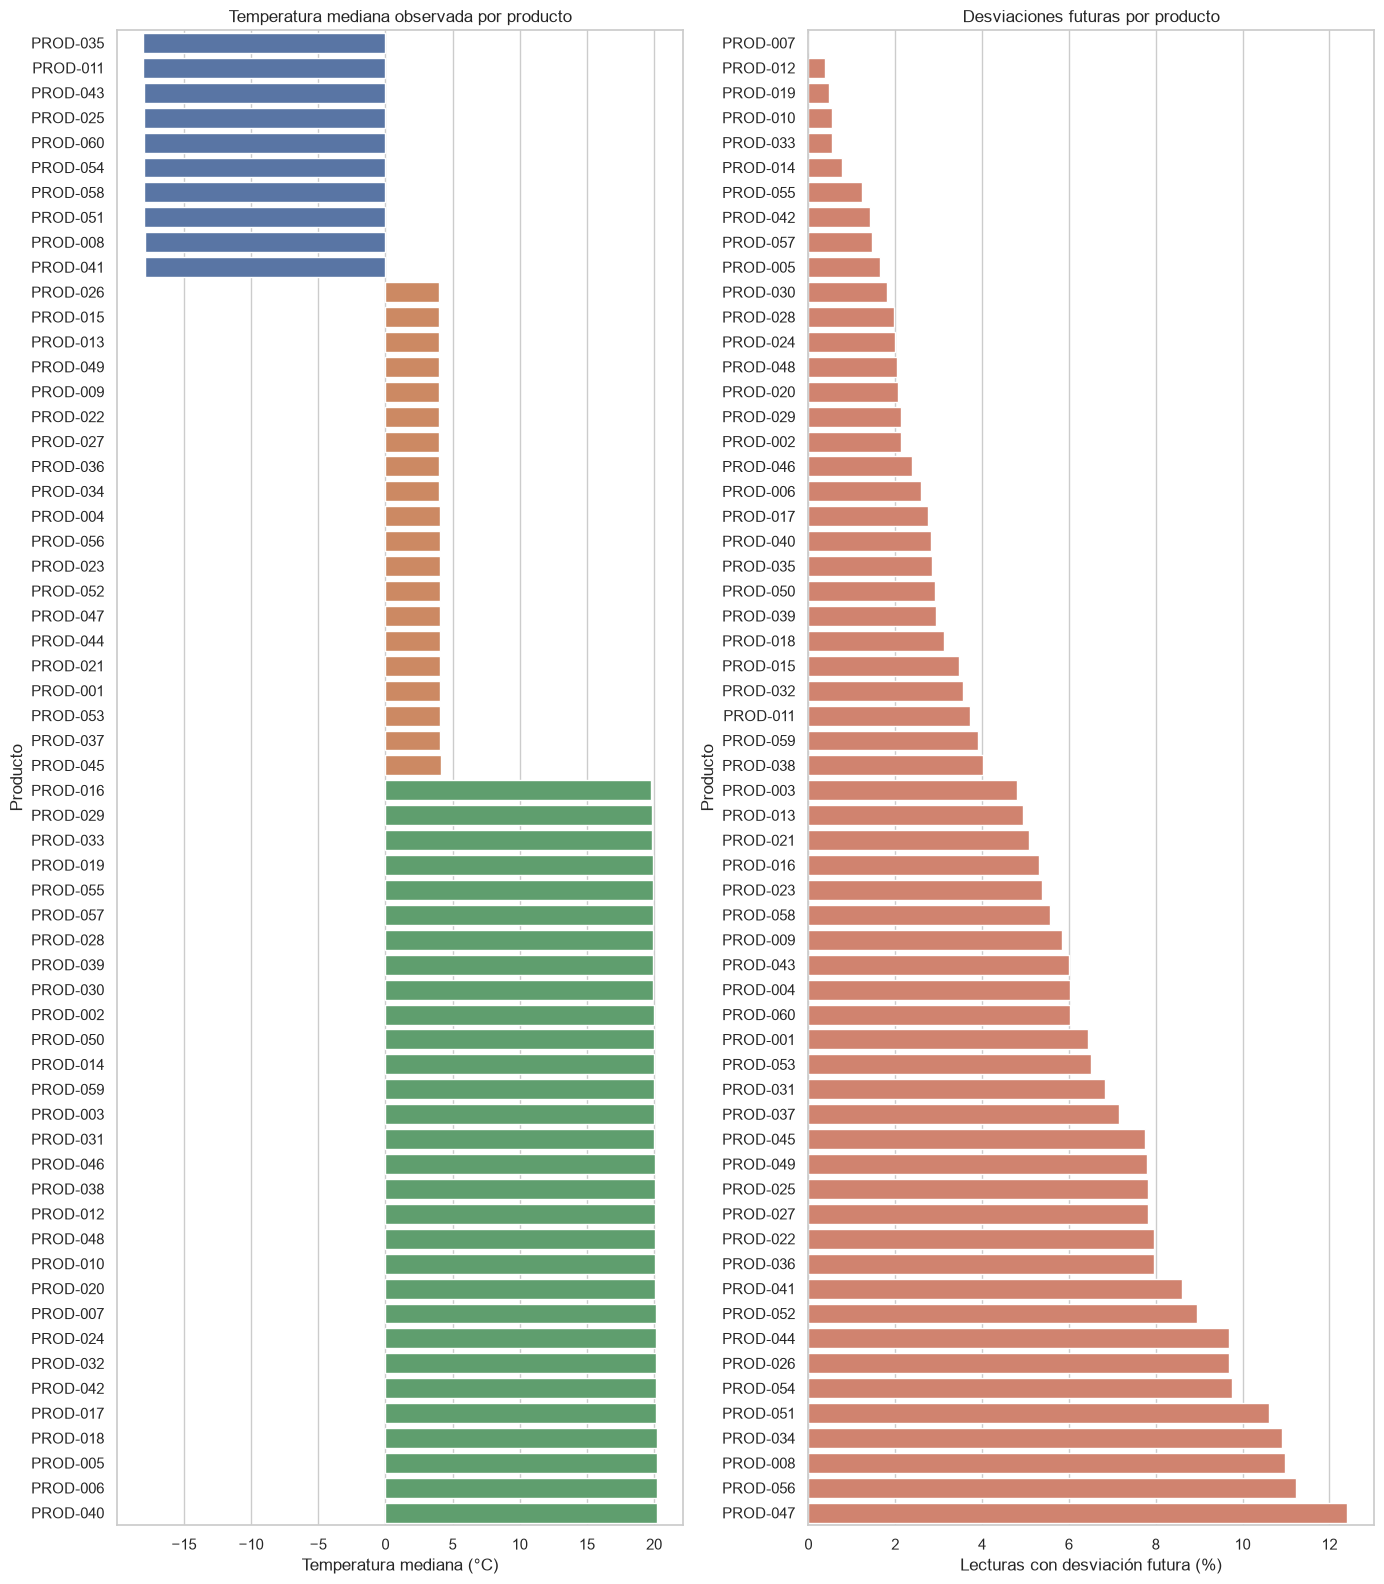

,productos,lecturas,temperatura_mediana,riesgo_futuro_pct
grupo_termico_observado,,,,
Mediana menor a 0 °C,10,4546,-17.96,7.44
Mediana entre 0 y 10 °C,20,8256,4.04,7.85
Mediana mayor o igual a 10 °C,30,12995,20.03,2.39


Productos con mayor porcentaje observado de desviación futura:


,lecturas,viajes,temperatura_mediana,desviaciones_futuras,riesgo_futuro_pct
producto_id,,,,,
PROD-047,403,19,4.08,50,12.41
PROD-056,543,25,4.04,61,11.23
PROD-008,492,23,-17.89,54,10.98
PROD-034,477,22,4.02,52,10.90
PROD-051,584,27,-17.94,62,10.62


In [16]:
resumen_producto = (
    analisis.groupby("producto_id")
    .agg(
        lecturas=("producto_id", "size"),
        viajes=("viaje_id", "nunique"),
        temperatura_mediana=(temp, "median"),
        temperatura_minima=(temp, "min"),
        temperatura_maxima=(temp, "max"),
        desviaciones_futuras=(objetivo, "sum"),
        riesgo_futuro_pct=(objetivo, "mean"),
    )
)
resumen_producto["riesgo_futuro_pct"] *= 100
resumen_producto["grupo_termico_observado"] = pd.cut(
    resumen_producto["temperatura_mediana"],
    bins=[-np.inf, 0, 10, np.inf],
    labels=["Mediana menor a 0 °C", "Mediana entre 0 y 10 °C", "Mediana mayor o igual a 10 °C"],
    right=False,
)

display(resumen_producto.sort_values("temperatura_mediana").round(2))

orden_temperatura = resumen_producto.sort_values("temperatura_mediana").index
orden_riesgo = resumen_producto.sort_values("riesgo_futuro_pct").index

fig, axes = plt.subplots(1, 2, figsize=(14, 16))
sns.barplot(
    data=resumen_producto.loc[orden_temperatura].reset_index(),
    y="producto_id", x="temperatura_mediana", hue="grupo_termico_observado",
    dodge=False, ax=axes[0], legend=False,
)
axes[0].set_title("Temperatura mediana observada por producto")
axes[0].set_xlabel("Temperatura mediana (°C)")
axes[0].set_ylabel("Producto")

sns.barplot(
    data=resumen_producto.loc[orden_riesgo].reset_index(),
    y="producto_id", x="riesgo_futuro_pct", color="#E07A5F", ax=axes[1],
)
axes[1].set_title("Desviaciones futuras por producto")
axes[1].set_xlabel("Lecturas con desviación futura (%)")
axes[1].set_ylabel("Producto")

plt.tight_layout()
plt.show()

resumen_grupo_termico = (
    analisis.assign(
        grupo_termico_observado=analisis["producto_id"].map(
            resumen_producto["grupo_termico_observado"]
        )
    )
    .groupby("grupo_termico_observado", observed=True)
    .agg(
        productos=("producto_id", "nunique"),
        lecturas=("producto_id", "size"),
        temperatura_mediana=(temp, "median"),
        riesgo_futuro_pct=(objetivo, "mean"),
    )
)
resumen_grupo_termico["riesgo_futuro_pct"] *= 100
display(resumen_grupo_termico.round(2))

print("Productos con mayor porcentaje observado de desviación futura:")
display(
    resumen_producto.nlargest(5, "riesgo_futuro_pct")[[
        "lecturas", "viajes", "temperatura_mediana",
        "desviaciones_futuras", "riesgo_futuro_pct",
    ]].round(2)
)

### Interpretación sencilla del análisis por producto

La segmentación confirma que no todos los productos trabajan alrededor de la misma temperatura. En los datos aparecen tres grupos claramente distintos:

- **10 productos** tienen una temperatura mediana menor a 0 °C, cercana a **−17,96 °C**. En este grupo, **7,44%** de las lecturas presenta una desviación futura.
- **20 productos** tienen una mediana entre 0 °C y 10 °C, cercana a **4,04 °C**. En este grupo, el riesgo futuro es **7,85%**.
- **30 productos** tienen una mediana mayor o igual a 10 °C, cercana a **20,03 °C**. En este grupo, el riesgo futuro baja a **2,39%**.

Por eso una temperatura baja no debe calificarse como riesgosa sin saber qué producto se transporta. Cerca de −18 °C puede ser el comportamiento habitual de un producto congelado, mientras que otro producto se mantiene alrededor de 4 °C o 20 °C.

Los porcentajes más altos por producto se observan en `PROD-047` (12,41%), `PROD-056` (11,23%), `PROD-008` (10,98%), `PROD-034` (10,90%) y `PROD-051` (10,62%). Esto no demuestra que el producto cause la desviación: también pueden influir el camión, la duración del viaje, la ruta y las condiciones de operación.

**Conclusión práctica:** los gráficos generales de temperatura mezclan productos con necesidades térmicas distintas y deben interpretarse con precaución. La comparación por producto ofrece una lectura más justa del riesgo. Para afirmar si una temperatura cumple o incumple una condición comercial todavía se necesita una tabla oficial con el rango permitido para cada producto.

## 5. Gráfico temporal opcional

**Pregunta que responde: ¿Cómo evoluciona la temperatura en algunos viajes y cuándo aparece una desviación futura?**

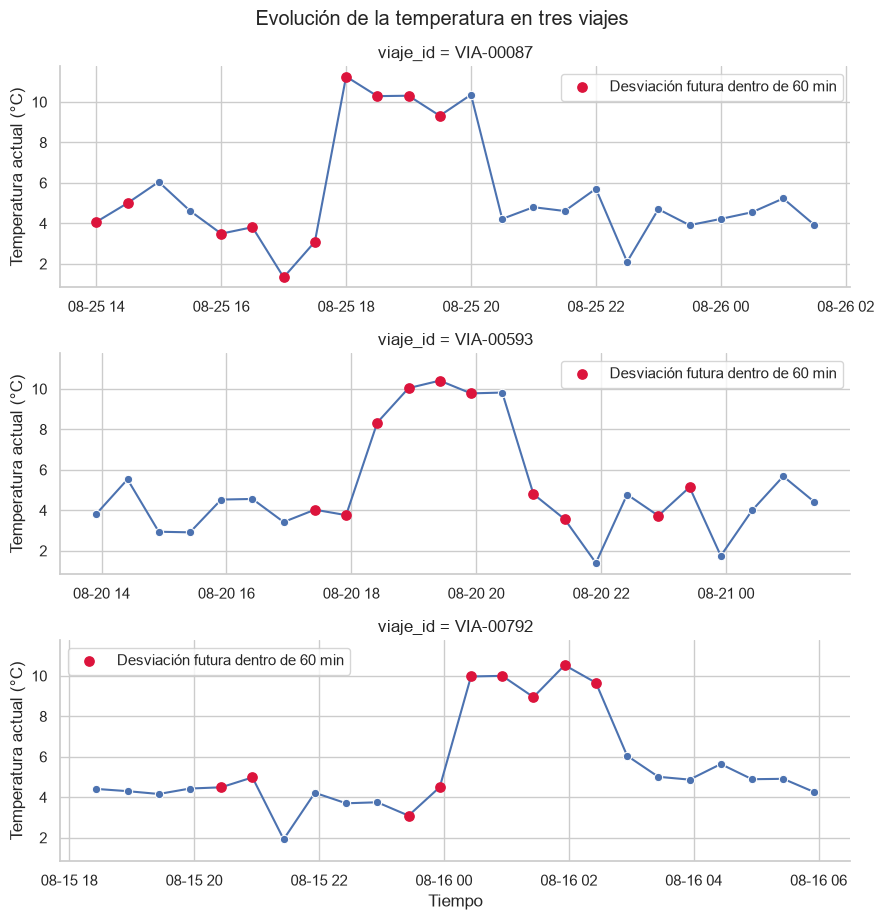

In [17]:
# Se eligen tres viajes con casos positivos para que el marcador pueda observarse.
seleccion = (
    analisis.groupby("viaje_id")[objetivo]
    .agg(positivos="sum", lecturas="size")
    .query("positivos > 0")
    .sort_values(["positivos", "lecturas"], ascending=False)
    .head(3)
)
viajes = seleccion.index.tolist()
panel = gold.loc[gold["viaje_id"].isin(viajes)].copy()

g = sns.relplot(
    data=panel, x="timestamp", y=temp, col="viaje_id", col_wrap=1,
    kind="line", marker="o", height=3, aspect=3, facet_kws={"sharex": False},
)
for ax, viaje in zip(g.axes.flat, viajes):
    positivos = panel.loc[(panel["viaje_id"] == viaje) & (panel[objetivo] == 1)]
    ax.scatter(
        positivos["timestamp"], positivos[temp], color="crimson", s=45,
        label="Desviación futura dentro de 60 min", zorder=5,
    )
    ax.legend()
g.set_axis_labels("Tiempo", "Temperatura actual (°C)")
g.fig.suptitle("Evolución de la temperatura en tres viajes", y=1.02)
plt.show()

In [18]:
print("Pregunta que responde: ¿Cómo evoluciona la temperatura en algunos viajes y cuándo aparece una desviación futura?")
resumen_viajes = panel.groupby("viaje_id").agg(
    lecturas=(temp, "size"),
    temperatura_minima=(temp, "min"),
    temperatura_maxima=(temp, "max"),
    desviaciones_futuras=(objetivo, lambda s: int((s == 1).sum())),
).round(2)
display(resumen_viajes)
print("Interpretación sencilla: la línea muestra cómo cambia la temperatura y los puntos rojos señalan desde qué lecturas aparece una desviación dentro de la hora siguiente.")
print("Estos tres viajes sirven como ejemplo visual; no representan necesariamente a todos los viajes.")

Pregunta que responde: ¿Cómo evoluciona la temperatura en algunos viajes y cuándo aparece una desviación futura?


,lecturas,temperatura_minima,temperatura_maxima,desviaciones_futuras
viaje_id,,,,
VIA-00087,24,1.33,11.26,10
VIA-00593,24,1.40,10.41,10
VIA-00792,24,1.92,10.53,9


Interpretación sencilla: la línea muestra cómo cambia la temperatura y los puntos rojos señalan desde qué lecturas aparece una desviación dentro de la hora siguiente.
Estos tres viajes sirven como ejemplo visual; no representan necesariamente a todos los viajes.


### Interpretación del gráfico temporal opcional

**Pregunta que responde: ¿Cómo evoluciona la temperatura en algunos viajes y cuándo aparece una desviación futura?**

La línea muestra cómo cambia la temperatura a medida que avanza cada viaje. Los puntos rojos no significan necesariamente que la lectura actual ya esté fuera de rango; indican que, desde ese momento, se sabe que aparecerá al menos una desviación durante los siguientes 60 minutos.

Se muestran tres viajes como ejemplos:

- `VIA-00087`: 24 lecturas, temperaturas entre **1,33 °C y 11,26 °C**, y 10 lecturas asociadas con una desviación futura.
- `VIA-00593`: 24 lecturas, temperaturas entre **1,40 °C y 10,41 °C**, y 10 lecturas asociadas con una desviación futura.
- `VIA-00792`: 24 lecturas, temperaturas entre **1,92 °C y 10,53 °C**, y 9 lecturas asociadas con una desviación futura.

**Conclusión práctica:** el gráfico permite ver la secuencia de los hechos y no solo valores aislados. Los puntos rojos muestran desde qué momentos comenzó a existir riesgo futuro en estos viajes concretos. Estos tres recorridos fueron elegidos porque contienen casos positivos y sirven para ilustrar el fenómeno; no deben considerarse una representación exacta de todos los viajes.

## 6. Informe de resultados

In [19]:
grupos_eda_informe = "\n".join(
    f"- {grupo}: {int(fila['productos'])} productos, temperatura mediana "
    f"{fila['temperatura_mediana']:.2f} °C y desviación futura {fila['riesgo_futuro_pct']:.2f}%"
    for grupo, fila in resumen_grupo_termico.iterrows()
)

top_productos_informe = "\n".join(
    f"- {producto}: temperatura mediana {fila['temperatura_mediana']:.2f} °C; "
    f"desviación futura {fila['riesgo_futuro_pct']:.2f}%"
    for producto, fila in resumen_producto.nlargest(5, 'riesgo_futuro_pct').iterrows()
)

informe = f'''# Informe 04 — Análisis exploratorio de la tabla Gold IoT

## 1. Propósito

Este informe explica qué contiene la tabla Gold y qué patrones aparecen antes de una desviación térmica. El objetivo vale 0 cuando no ocurre una desviación durante los siguientes 60 minutos y 1 cuando sí ocurre. El análisis es descriptivo: no demuestra causalidad ni realiza todavía una predicción.

## 2. Población y calidad estructural

- Filas Gold: {len(gold):,}
- Columnas: {gold.shape[1]}
- Viajes: {gold['viaje_id'].nunique():,}
- Ventanas evaluables: {len(analisis):,}
- Ventanas no evaluables: {gold[objetivo].isna().sum():,}
- Duplicados por viaje + timestamp: {gold.duplicated(['viaje_id', 'timestamp']).sum():,}

Cada fila representa una lectura de telemetría de un viaje en un momento determinado. La ausencia de claves repetidas indica que los cruces no multiplicaron lecturas.

## 3. Valores vacíos

- Temperatura anterior: {gold['temperatura_anterior'].isna().sum():,} vacíos ({gold['temperatura_anterior'].isna().mean() * 100:.2f}%). Aparecen principalmente al inicio de cada viaje, cuando todavía no existe una lectura anterior.
- Variación de temperatura en 30 minutos: {gold['variacion_temperatura_30min'].isna().sum():,} vacíos ({gold['variacion_temperatura_30min'].isna().mean() * 100:.2f}%). No existe una lectura anterior suficientemente cercana para calcularla.
- Objetivo futuro: {gold[objetivo].isna().sum():,} vacíos ({gold[objetivo].isna().mean() * 100:.2f}%). El viaje termina antes de completar los 60 minutos futuros.

Estos vacíos tienen una explicación temporal y no representan necesariamente fallas de los sensores. No se encontraron faltantes inesperados. Las ventanas sin futuro completo se conservan en Gold, pero no se usan en los gráficos del objetivo.

## 4. Respuestas a las preguntas

### 4.1 ¿Qué tan poco frecuentes son las desviaciones futuras?

Se observan {conteos[1]:,} casos positivos de {len(analisis):,} ventanas evaluables, equivalentes al {porcentajes[1]:.2f}%. En palabras sencillas, cerca de 5 de cada 100 lecturas anuncian una desviación futura. Por eso el modelo posterior deberá prestar atención a una clase poco frecuente.

### 4.2 ¿Las futuras desviaciones parten de temperaturas diferentes?

La mediana es {med_temp[0]:.2f} °C sin desviación futura y {med_temp[1]:.2f} °C con desviación futura. La diferencia es {abs(diferencia_temp):.2f} °C. Las desviaciones futuras parten, en general, de temperaturas más bajas, aunque existe superposición y una temperatura aislada no determina el resultado.

### 4.3 ¿La humedad cambia antes de una desviación?

La mediana es {med_humedad[0]:.2f}% sin desviación futura y {med_humedad[1]:.2f}% con desviación futura. La diferencia es {abs(diferencia_humedad):.2f} puntos porcentuales. Los casos futuros se asocian con mayor humedad, pero la humedad no debe utilizarse sola como regla automática.

### 4.4 ¿Una desviación presente anticipa otra en la siguiente hora?

La frecuencia futura es {tasas_actual[0] * 100:.2f}% sin desviación actual y {tasas_actual[1] * 100:.2f}% con desviación actual. La diferencia es {abs(diferencia_tasa):.2f} puntos porcentuales. La desviación actual es la señal más clara, aunque no es una regla perfecta y no identifica por sí misma todos los eventos nuevos.

### 4.5 ¿La combinación de nivel y tendencia permite reconocer el riesgo?

El grupo con riesgo difiere {dif_nivel:+.2f} °C en nivel y {dif_tendencia:+.2f} °C en variación de 30 minutos respecto al grupo sin riesgo. La diferencia principal está en el nivel de temperatura. La superposición de colores indica que ambas variables aportan contexto, pero no separan todos los casos.


## 5. Análisis por producto

La comparación por producto muestra tres niveles térmicos observados: medianas cercanas a -18 °C, 4 °C y 20 °C. Esto confirma que la temperatura no debe interpretarse de la misma manera para todos los productos.

{grupos_eda_informe}

Los mayores porcentajes observados de desviación futura corresponden a:

{top_productos_informe}

Estos porcentajes describen asociaciones históricas y no prueban que el producto sea la causa. Los grupos térmicos son resúmenes de los datos observados, no rangos permitidos. Para evaluar cumplimiento se necesita una tabla oficial con los límites por producto.

## 6. Gráfico temporal opcional

Los tres viajes seleccionados permiten observar la secuencia de la temperatura y los momentos desde los que aparece riesgo durante la hora siguiente. Son ejemplos con casos positivos y no representan necesariamente a todos los viajes.

## 7. Conclusiones

- La estructura Gold es consistente y no presenta multiplicación de lecturas.
- Los vacíos observados tienen explicaciones temporales.
- Las desviaciones futuras son poco frecuentes.
- Temperatura, humedad, desviación actual y tendencia contienen señales descriptivas.
- La desviación actual es la señal más marcada, lo que anticipa que reconocer problemas nuevos será más difícil que reconocer la continuidad de uno existente.

## 8. Limitaciones

- El análisis es descriptivo y no demuestra causalidad.
- Los patrones históricos pueden cambiar en viajes nuevos.
- Las ventanas no evaluables no participan en los gráficos del objetivo.
- El gráfico temporal muestra solamente tres viajes con casos positivos.
- Ninguna diferencia observada garantiza por sí sola una buena predicción.
- No se proporcionaron rangos térmicos permitidos por producto; los grupos mostrados son descriptivos.

Ejecución UTC: {datetime.now(timezone.utc).isoformat()}
'''

RUTA_INFORME.write_text(informe, encoding="utf-8")
print("Informe generado:", RUTA_INFORME.resolve())

Informe generado: C:\Users\remrodri\Documents\Codex\2026-09-28\referenced-chatgpt-conversation-this-is-an\outputs\04_eda_gold_iot\Informe_04_EDA_Gold_IoT.md


## 7. Conclusiones generales y limitaciones

### Conclusiones generales

1. La tabla Gold conserva una lectura por viaje y momento, sin evidencia de multiplicación de registros.
2. Los valores vacíos encontrados tienen explicaciones temporales: aparecen cuando no existe suficiente historia previa o tiempo futuro para calcular una variable. No se encontraron faltantes inesperados.
3. Las desviaciones futuras son poco frecuentes: aparecen en aproximadamente 5 de cada 100 lecturas evaluables.
4. Las lecturas con desviación futura presentan, en general, temperaturas más bajas y niveles de humedad más altos.
5. La señal más clara es la desviación térmica actual: el riesgo futuro es mucho mayor cuando la lectura ya está en desviación.
6. La variación de temperatura aporta contexto, pero no separa perfectamente los casos con y sin desviación futura.

Estos resultados justifican utilizar las cinco variables analizadas en el modelo de regresión logística. También anticipan una dificultad: detectar una desviación **antes de que el problema sea visible en la lectura actual** será más difícil que reconocer la continuación de una desviación que ya comenzó.

### Limitaciones que deben recordarse

- El análisis describe asociaciones observadas; no demuestra que una variable cause una desviación.
- Las diferencias corresponden a estos datos históricos y podrían cambiar en viajes nuevos.
- Las 2.668 ventanas no evaluables permanecen en Gold, pero no participan en los gráficos del objetivo.
- Los gráficos resumen patrones generales y pueden ocultar diferencias particulares entre viajes, productos o camiones.
- El gráfico temporal opcional muestra solo tres viajes seleccionados porque contienen casos positivos.
- Una variable que presenta diferencias entre grupos no necesariamente será suficiente para predecir correctamente por sí sola.

El EDA obligatorio queda completo y explicado dentro del notebook. El informe Markdown generado al final conserva la misma información como material adicional de consulta.